# Notebook 17 — Strict OCV / ICA / DVA Feasibility Audit

## Goal

This notebook audits whether the SEI-only aging branch can support a strict OCV-like voltage-curve diagnostic and derivative-based ICA/DVA features.

The purpose is not to claim a validated OCV diagnostic immediately, but to determine whether a low-rate or quasi-equilibrium diagnostic protocol can produce sufficiently smooth and interpretable voltage–capacity curves for later aging-fingerprint analysis.

## Scientific context

Notebook 16 established a fixed-endpoint pseudo-OCV layer:

- full-charge preconditioning,
- C/3 discharge to a fixed loaded terminal-voltage endpoint,
- finite 60 min rest,
- evaluation of U00_after_fixed_rest and recovery descriptors.

That layer is useful as a finite-rest voltage-recovery descriptor, but it is not strict OCV and must not be interpreted as an OCV-SOC curve.

Notebook 17 therefore separates the next question:

Can a dedicated low-rate diagnostic branch produce OCV-like V(Q), ICA dQ/dV, and DVA dV/dQ features that are technically extractable and physically interpretable under SEI-only aging?

## Study design

Aging branch:

- Parameter set: OKane2022
- Aging mechanism: solvent-diffusion-limited SEI only
- Plating: disabled
- LAM: disabled
- particle mechanics: disabled
- SEI porosity change: disabled

Checkpoints:

- 0 cycles
- 3 cycles
- 10 cycles
- 20 cycles

Diagnostic branch:

- start from the pre-diagnostic full-charge-rest checkpoint state produced by the aging protocol
- for the 0-cycle reference, start from initial_soc = 1.0
- low-rate discharge over the usable voltage window
- extraction of voltage–capacity curve V(Q)
- smoothing / monotonicity audit
- ICA: dQ/dV
- DVA: dV/dQ

## Workflow

1. Rebuild or load SEI-only checkpoint states.
2. Run low-rate diagnostic discharge branches from each checkpoint.
3. Extract Q, V, nominal SOC, and time.
4. Audit voltage monotonicity and sampling density.
5. Generate OCV-like V(Q) overlay.
6. Compute derivative features only if curve quality is sufficient.
7. Classify ICA/DVA feasibility.

## Expected outputs

Data files:

- `data/strict_ocv_ica_dva_curve_table.csv`
- `data/strict_ocv_ica_dva_quality_audit.csv`
- `data/strict_ocv_ica_dva_feature_table.csv`
- `data/strict_ocv_ica_dva_classification_table.csv`

Figures:

- `figures/strict_ocv_like_VQ_overlay.png`
- `figures/strict_ocv_like_deltaV_vs_Q.png`
- `figures/strict_ocv_ica_overlay.png`
- `figures/strict_ocv_dva_overlay.png`

## Interpretation boundary

This notebook is a feasibility audit.

A smooth low-rate voltage curve may be called OCV-like or quasi-equilibrium, but it is not automatically a thermodynamic OCV curve unless the protocol is slow enough and relaxation effects are demonstrably negligible.

ICA and DVA features are only interpretable if the underlying V(Q) curve is sufficiently smooth, monotonic, and sampled with adequate resolution.

Unsupported or noisy derivative features must be classified as not_applicable or deferred rather than overinterpreted.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


## Methodological boundary before code execution

This notebook must not reuse the fixed-endpoint pseudo-OCV interpretation from Notebook 16.

Notebook 16 asked:

> At the same loaded terminal-voltage endpoint and after a finite rest, how do voltage-recovery descriptors change?

Notebook 17 asks:

> Under a dedicated low-rate diagnostic protocol, can the SEI-only branch generate sufficiently smooth voltage–capacity curves for OCV-like, ICA, and DVA analysis?

The diagnostic branch must not be used to continue aging. Aging always continues from the pre-diagnostic aging state.

In [2]:
# Cell 2 — SEI-only OKane2022 model builder（SEI-only OKane2022 模型构建函数）

def build_sei_only_model():
    """
    Build DFN model with solvent-diffusion-limited SEI only.
    Other degradation mechanisms are disabled to keep the fingerprint source isolated.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }
    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")
    return model, parameter_values


model_smoke, pv_smoke = build_sei_only_model()

print("[OK] SEI-only OKane2022 DFN model instantiated.")
print("[MODEL]", model_smoke.name)

[OK] SEI-only OKane2022 DFN model instantiated.
[MODEL] Doyle-Fuller-Newman model


In [3]:
# Cell 3 — Protocol constants and checkpoint definition（协议常数与检查点定义）

CHECKPOINT_CYCLES = [0, 3, 10, 20]

# Diagnostic protocol choices
LOW_RATE = "C/25"      # initial feasibility choice for OCV-like voltage curve
V_MIN = 2.5
V_MAX = 4.2

# Full-charge preconditioning before low-rate diagnostic
PRECONDITIONING_STEPS = [
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

# Low-rate OCV-like diagnostic branch
OCV_LIKE_STEPS = [
    f"Discharge at {LOW_RATE} until {V_MIN} V",
    "Rest for 60 minutes",
]

print("[CONFIG] checkpoints:", CHECKPOINT_CYCLES)
print("[CONFIG] low-rate diagnostic:", LOW_RATE)
print("[CONFIG] voltage window:", V_MIN, "to", V_MAX, "V")
print("[OK] Protocol constants defined.")

[CONFIG] checkpoints: [0, 3, 10, 20]
[CONFIG] low-rate diagnostic: C/25
[CONFIG] voltage window: 2.5 to 4.2 V
[OK] Protocol constants defined.


In [4]:
# Cell 4 — SEI-only aging checkpoint runner（SEI-only 老化检查点生成函数）

def make_solver():
    """Create a conservative CasADi solver for degradation-enabled DFN runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]


def make_aging_experiment(n_cycles, period="120 seconds"):
    """Build repeated SEI-only aging experiment."""
    if n_cycles == 0:
        return None
    return pybamm.Experiment([tuple(AGING_CYCLE_STEPS)] * n_cycles, period=period)


def run_aging_segment(n_cycles, starting_solution=None, initial_soc=None):
    """
    Run n_cycles of SEI-only aging.

    The returned solution is a pre-diagnostic aging state.
    Diagnostic branches must start from this solution, but must not be used
    to continue aging.
    """
    if n_cycles == 0:
        return starting_solution

    model, pv = build_sei_only_model()
    experiment = make_aging_experiment(n_cycles)
    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    if initial_soc is not None:
        kwargs["initial_soc"] = initial_soc

    sol = sim.solve(**kwargs)
    return sol


checkpoint_solutions = {0: None}

current_solution = None
current_cycle = 0

for target_cycle in CHECKPOINT_CYCLES[1:]:
    n_more = target_cycle - current_cycle
    print(f"[RUN] Aging from cycle {current_cycle} to {target_cycle} ({n_more} cycles)")
    current_solution = run_aging_segment(
        n_cycles=n_more,
        starting_solution=current_solution,
        initial_soc=1.0 if current_cycle == 0 else None,
    )
    checkpoint_solutions[target_cycle] = current_solution
    current_cycle = target_cycle
    print(f"[OK] checkpoint stored: {target_cycle} cycles")

print("[OK] Aging checkpoint generation complete.")
print("[CHECKPOINTS]", sorted(checkpoint_solutions.keys()))

[RUN] Aging from cycle 0 to 3 (3 cycles)
[OK] checkpoint stored: 3 cycles
[RUN] Aging from cycle 3 to 10 (7 cycles)
[OK] checkpoint stored: 10 cycles
[RUN] Aging from cycle 10 to 20 (10 cycles)
[OK] checkpoint stored: 20 cycles
[OK] Aging checkpoint generation complete.
[CHECKPOINTS] [0, 3, 10, 20]


In [7]:
# Cell 5 — Diagnostic-only low-rate OCV-like branch runner（仅诊断低倍率 OCV-like 分支运行函数）

def make_ocv_like_experiment(period="60 seconds"):
    """
    Build diagnostic-only low-rate branch.

    The full-charge-rest state is inherited from the aging checkpoint.
    For the 0-cycle reference, initial_soc=1.0 is used.

    This branch must never be used to continue aging.
    """
    return pybamm.Experiment(OCV_LIKE_STEPS, period=period)


def run_ocv_like_diagnostic(checkpoint_cycle, starting_solution=None):
    """
    Run low-rate discharge diagnostic branch from a pre-diagnostic aging checkpoint.

    No repeated full-charge preconditioning is applied here because the aging
    checkpoint already ends after charge-to-4.2V, CV hold, and 10 min rest.
    """
    model, pv = build_sei_only_model()
    experiment = make_ocv_like_experiment(period="60 seconds")

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] OCV-like diagnostic-only branch at {checkpoint_cycle} cycles")
    sol = sim.solve(**kwargs)
    print(f"[OK] diagnostic solved: {checkpoint_cycle} cycles")
    return sol


diagnostic_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    diagnostic_solutions[cycle] = run_ocv_like_diagnostic(
        checkpoint_cycle=cycle,
        starting_solution=checkpoint_solutions[cycle],
    )

print("[OK] All diagnostic-only OCV-like branches solved.")

[RUN] OCV-like diagnostic-only branch at 0 cycles
[OK] diagnostic solved: 0 cycles
[RUN] OCV-like diagnostic-only branch at 3 cycles
[OK] diagnostic solved: 3 cycles
[RUN] OCV-like diagnostic-only branch at 10 cycles
[OK] diagnostic solved: 10 cycles
[RUN] OCV-like diagnostic-only branch at 20 cycles
[OK] diagnostic solved: 20 cycles
[OK] All diagnostic-only OCV-like branches solved.


In [8]:
# Cell 5A — Selected low-rate diagnostic segment audit（选定低倍率诊断段审计）

def summarize_current_segments(sol, cycle, eps=1e-4):
    """
    Summarize sign-based current segments in a solution.

    PyBaMM sign convention:
    +I = discharge
    -I = charge
    near-zero = rest / near cutoff
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "cycle": cycle,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


all_segments = []
selected_segments = []

for cycle, sol in diagnostic_solutions.items():
    seg = summarize_current_segments(sol, cycle)
    all_segments.append(seg)

    # C/25 diagnostic discharge in OKane2022 is approximately 0.2 A
    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(0.15, 0.25))
        & (seg["duration_min"] > 1000)
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid C/25 diagnostic discharge segment found for cycle {cycle}")

    # Use the last matching segment because starting_solution includes aging history.
    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    selected["selection_rule"] = "last discharge segment with 0.15 A <= I_mean <= 0.25 A and duration > 1000 min"
    selected_segments.append(selected)

diagnostic_segment_audit = pd.concat(all_segments, ignore_index=True)
diagnostic_selected_segment_audit = pd.DataFrame(selected_segments)

segment_path = DATA / "strict_ocv_ica_dva_diagnostic_segment_audit.csv"
selected_path = DATA / "strict_ocv_ica_dva_selected_diagnostic_segment_audit.csv"

diagnostic_segment_audit.to_csv(segment_path, index=False)
diagnostic_selected_segment_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(diagnostic_selected_segment_audit[[
    "cycle", "segment_id", "duration_min", "U_start_V", "U_end_V",
    "I_mean_A", "n_points", "selection_rule"
]])

assert diagnostic_selected_segment_audit["duration_min"].between(1400, 1600).all()
assert diagnostic_selected_segment_audit["I_mean_A"].between(0.15, 0.25).all()

print("[OK] Selected low-rate diagnostic segments are valid for OCV-like V(Q) extraction.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_diagnostic_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_selected_diagnostic_segment_audit.csv


,cycle,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points,selection_rule
0,0,0,1530.187182,4.190343,2.50001,0.2,1532,last discharge segment with 0.15 A <= I_mean <...
1,3,12,1526.491561,4.184964,2.50001,0.2,1528,last discharge segment with 0.15 A <= I_mean <...
2,10,40,1526.093783,4.184947,2.50001,0.2,1528,last discharge segment with 0.15 A <= I_mean <...
3,20,80,1525.629718,4.184936,2.50001,0.2,1527,last discharge segment with 0.15 A <= I_mean <...


[OK] Selected low-rate diagnostic segments are valid for OCV-like V(Q) extraction.


In [9]:
# Cell 6 — Selected low-rate V(Q) curve extraction wrapper（选定低倍率 V(Q) 曲线提取封装）

def extract_selected_low_rate_discharge_curve(sol, cycle, selected_segment_table):
    """
    Extract the selected C/25 diagnostic discharge segment.

    This avoids confusing the diagnostic branch with the aging history carried
    by PyBaMM starting_solution.
    """
    selected = selected_segment_table[selected_segment_table["cycle"] == cycle]
    if selected.empty:
        raise RuntimeError(f"No selected diagnostic segment for cycle {cycle}")

    row = selected.iloc[0]
    a = int(row["idx_start"])
    b = int(row["idx_stop"])

    t = np.asarray(sol["Time [s]"].entries, dtype=float)[a:b]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[a:b]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[a:b]

    t_rel_s = t - t[0]

    q_Ah = np.zeros_like(t_rel_s)
    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    q_end_Ah = float(q_Ah[-1])
    nominal_soc = 1.0 - q_Ah / q_end_Ah if q_end_Ah > 0 else np.nan

    out = pd.DataFrame({
        "cycle": cycle,
        "t_rel_s": t_rel_s,
        "t_rel_h": t_rel_s / 3600.0,
        "Q_dis_Ah": q_Ah,
        "nominal_SOC": nominal_soc,
        "U_V": v,
        "I_A_pybamm": i,
        "segment_id": int(row["segment_id"]),
    })

    return out


curve_tables = []

for cycle, sol in diagnostic_solutions.items():
    df_curve = extract_selected_low_rate_discharge_curve(
        sol=sol,
        cycle=cycle,
        selected_segment_table=diagnostic_selected_segment_audit,
    )
    curve_tables.append(df_curve)

curve_table = pd.concat(curve_tables, ignore_index=True)

curve_path = DATA / "strict_ocv_ica_dva_curve_table.csv"
curve_table.to_csv(curve_path, index=False)

print(f"[OK] saved: {curve_path}")
print("[SHAPE]", curve_table.shape)

display(curve_table.groupby("cycle").agg(
    n_points=("Q_dis_Ah", "size"),
    Q_end_Ah=("Q_dis_Ah", "max"),
    U_start_V=("U_V", "first"),
    U_end_V=("U_V", "last"),
    I_mean_A=("I_A_pybamm", "mean"),
    t_end_h=("t_rel_h", "max"),
    selected_segment_id=("segment_id", "first"),
))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_curve_table.csv
[SHAPE] (6115, 8)


,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A,t_end_h,selected_segment_id
cycle,,,,,,,
0,1532,5.100624,4.190343,2.50001,0.2,25.503120,0
3,1528,5.088305,4.184964,2.50001,0.2,25.441526,12
10,1528,5.086979,4.184947,2.50001,0.2,25.434896,40
20,1527,5.085432,4.184936,2.50001,0.2,25.427162,80


In [10]:
# Cell 6A — Start-state and common-window audit（起点一致性与共同窗口审计）

curve_summary = (
    curve_table
    .groupby("cycle", as_index=False)
    .agg(
        n_points=("Q_dis_Ah", "size"),
        Q_end_Ah=("Q_dis_Ah", "max"),
        U_start_V=("U_V", "first"),
        U_end_V=("U_V", "last"),
        I_mean_A=("I_A_pybamm", "mean"),
        t_end_h=("t_rel_h", "max"),
        selected_segment_id=("segment_id", "first"),
    )
)

u_start_spread_mV = (
    curve_summary["U_start_V"].max() - curve_summary["U_start_V"].min()
) * 1000

q0 = float(curve_summary.loc[curve_summary["cycle"] == 0, "Q_end_Ah"].iloc[0])
q20 = float(curve_summary.loc[curve_summary["cycle"] == 20, "Q_end_Ah"].iloc[0])
capacity_fade_pct = (q0 - q20) / q0 * 100

q_common_max_Ah = float(curve_summary["Q_end_Ah"].min())

start_state_audit = pd.DataFrame([
    {
        "metric": "U_start_spread_mV",
        "value": u_start_spread_mV,
        "threshold": 10.0,
        "pass": bool(u_start_spread_mV <= 10.0),
        "interpretation": "start-voltage spread before C/25 diagnostic discharge",
    },
    {
        "metric": "Q_common_max_Ah",
        "value": q_common_max_Ah,
        "threshold": np.nan,
        "pass": True,
        "interpretation": "common Q-window upper bound across all checkpoints",
    },
    {
        "metric": "capacity_fade_0_to_20_pct",
        "value": capacity_fade_pct,
        "threshold": np.nan,
        "pass": True,
        "interpretation": "low-rate discharge capacity fade from 0 to 20 cycles",
    },
])

summary_path = DATA / "strict_ocv_ica_dva_curve_summary.csv"
audit_path = DATA / "strict_ocv_ica_dva_start_state_audit.csv"

curve_summary.to_csv(summary_path, index=False)
start_state_audit.to_csv(audit_path, index=False)

print(f"[OK] saved: {summary_path}")
print(f"[OK] saved: {audit_path}")

display(curve_summary)
display(start_state_audit)

if u_start_spread_mV > 5.0:
    print(
        f"[WARNING] U_start spread = {u_start_spread_mV:.3f} mV. "
        "This is acceptable for feasibility-level OCV-like analysis, "
        "but early-Q derivative interpretation should be conservative."
    )

assert u_start_spread_mV <= 10.0, "Start-voltage spread too large for this feasibility audit."

print("[OK] Start-state and common-window audit passed.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_curve_summary.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_start_state_audit.csv


,cycle,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A,t_end_h,selected_segment_id
0,0,1532,5.100624,4.190343,2.50001,0.2,25.503120,0
1,3,1528,5.088305,4.184964,2.50001,0.2,25.441526,12
2,10,1528,5.086979,4.184947,2.50001,0.2,25.434896,40
3,20,1527,5.085432,4.184936,2.50001,0.2,25.427162,80


,metric,value,threshold,pass,interpretation
0,U_start_spread_mV,5.407202,10.0,True,start-voltage spread before C/25 diagnostic di...
1,Q_common_max_Ah,5.085432,NaN,True,common Q-window upper bound across all checkpo...
2,capacity_fade_0_to_20_pct,0.297837,NaN,True,low-rate discharge capacity fade from 0 to 20 ...


[WARNING] U_start spread = 5.407 mV. This is acceptable for feasibility-level OCV-like analysis, but early-Q derivative interpretation should be conservative.
[OK] Start-state and common-window audit passed.


In [11]:
# Cell 7 — V(Q) quality audit for ICA/DVA feasibility（V(Q) 曲线质量审计）

quality_rows = []

for cycle, g in curve_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    dQ = np.diff(g["Q_dis_Ah"].to_numpy())
    dV = np.diff(g["U_V"].to_numpy())

    n_points = len(g)
    q_end = float(g["Q_dis_Ah"].iloc[-1])
    v_start = float(g["U_V"].iloc[0])
    v_end = float(g["U_V"].iloc[-1])
    voltage_span = v_start - v_end

    q_nonmono = int(np.sum(dQ <= 0))
    v_increase_count = int(np.sum(dV > 1e-5))
    v_increase_fraction = v_increase_count / max(len(dV), 1)

    median_dQ_mAh = float(np.median(dQ) * 1000) if len(dQ) else np.nan
    median_dV_mV = float(np.median(np.abs(dV)) * 1000) if len(dV) else np.nan

    pass_quality = (
        n_points >= 500
        and q_end > 1.0
        and voltage_span > 1.0
        and q_nonmono == 0
        and v_increase_fraction < 0.01
    )

    quality_rows.append({
        "cycle": cycle,
        "n_points": n_points,
        "Q_end_Ah": q_end,
        "U_start_V": v_start,
        "U_end_V": v_end,
        "voltage_span_V": voltage_span,
        "Q_nonmonotonic_count": q_nonmono,
        "V_local_increase_count": v_increase_count,
        "V_local_increase_fraction": v_increase_fraction,
        "median_dQ_mAh": median_dQ_mAh,
        "median_abs_dV_mV": median_dV_mV,
        "pass_curve_quality": pass_quality,
    })

quality_audit = pd.DataFrame(quality_rows)

quality_path = DATA / "strict_ocv_ica_dva_quality_audit.csv"
quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(quality_audit)

assert quality_audit["pass_curve_quality"].all(), "At least one curve failed quality audit; ICA/DVA should be deferred."
print("[OK] All curves passed basic V(Q) quality audit.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_quality_audit.csv


,cycle,n_points,Q_end_Ah,U_start_V,U_end_V,voltage_span_V,Q_nonmonotonic_count,V_local_increase_count,V_local_increase_fraction,median_dQ_mAh,median_abs_dV_mV,pass_curve_quality
0,0,1532,5.100624,4.190343,2.50001,1.690333,0,2,0.001306,3.333333,0.594799,True
1,3,1528,5.088305,4.184964,2.50001,1.684954,0,2,0.001310,3.333333,0.593814,True
2,10,1528,5.086979,4.184947,2.50001,1.684937,0,2,0.001310,3.333333,0.595027,True
3,20,1527,5.085432,4.184936,2.50001,1.684926,0,1,0.000655,3.333333,0.594102,True


[OK] All curves passed basic V(Q) quality audit.


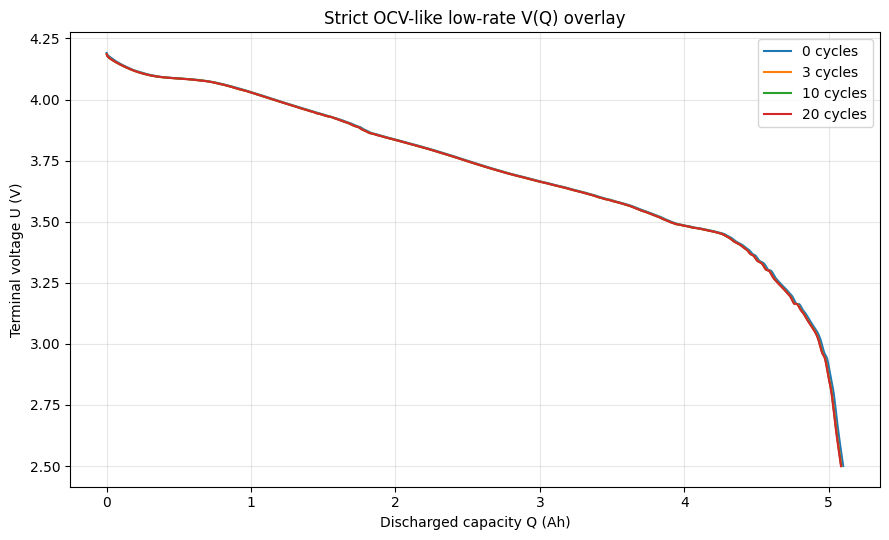

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/strict_ocv_like_VQ_overlay.png


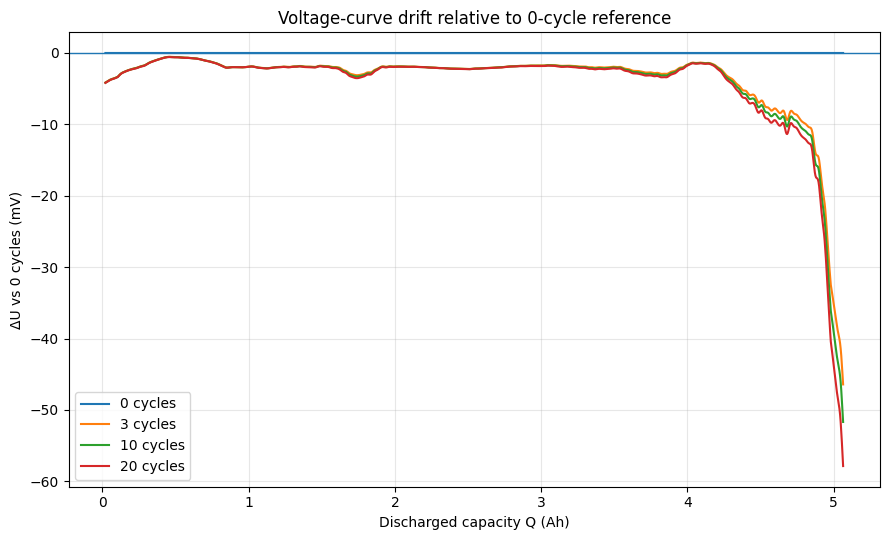

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/strict_ocv_like_deltaV_vs_Q.png


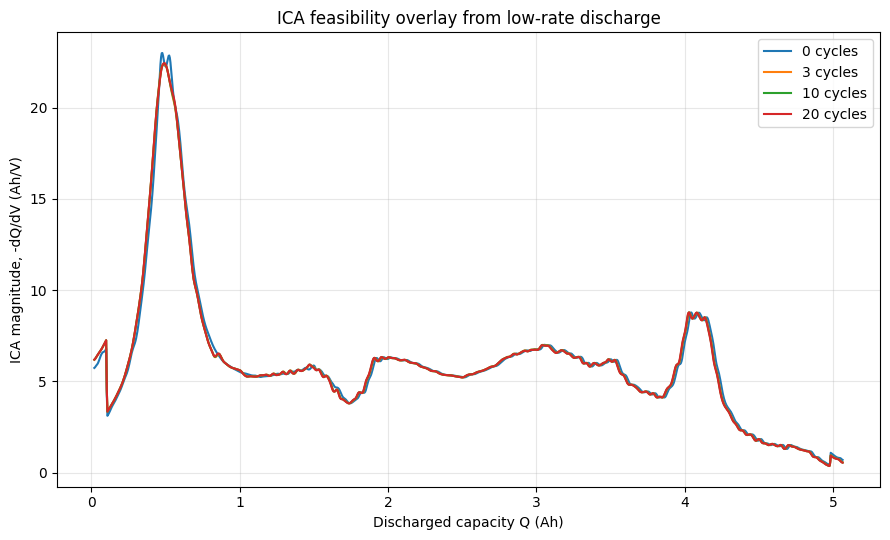

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/strict_ocv_ica_overlay.png


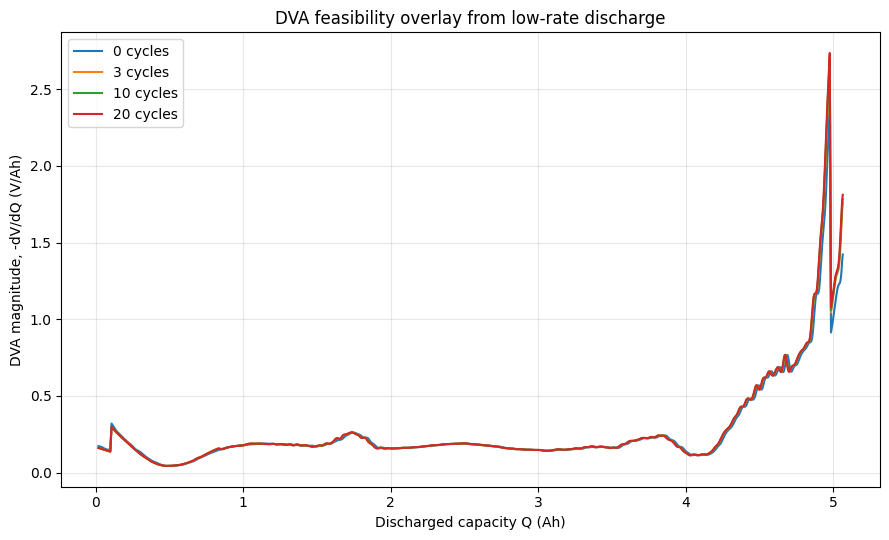

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/strict_ocv_dva_overlay.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_feature_table.csv


,cycle,Q_common_max_Ah,ICA_peak_mag_Ah_per_V,ICA_peak_Q_Ah,ICA_peak_U_V,DVA_median_mag_V_per_Ah,DVA_peak_mag_V_per_Ah
0,0,5.085432,22.998392,0.478676,4.087313,0.177562,2.424937
1,3,5.085432,22.376765,0.487092,4.086380,0.177441,2.678014
2,10,5.085432,22.404718,0.491300,4.086173,0.177497,2.704329
3,20,5.085432,22.449489,0.491300,4.086152,0.177587,2.734796


In [12]:
# Cell 8 — OCV-like V(Q), delta-V, ICA, and DVA visualization（OCV-like 曲线与 ICA/DVA 可视化）

def smooth_centered(y, window=41):
    """Simple centered rolling mean smoothing."""
    s = pd.Series(y)
    return s.rolling(window=window, center=True, min_periods=max(3, window // 5)).mean().bfill().ffill().to_numpy()


# common Q grid across all checkpoints
q_common_max = curve_table.groupby("cycle")["Q_dis_Ah"].max().min()
q_grid = np.linspace(0.02, q_common_max - 0.02, 1200)

interp_rows = []
feature_rows = []

for cycle, g in curve_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)
    q = g["Q_dis_Ah"].to_numpy()
    v = g["U_V"].to_numpy()

    v_interp = np.interp(q_grid, q, v)
    v_smooth = smooth_centered(v_interp, window=41)

    dVdQ = np.gradient(v_smooth, q_grid)
    # discharge curve has dV/dQ < 0; use positive magnitudes for feature visualization
    dva_mag = -dVdQ
    ica_mag = np.where(np.abs(dVdQ) > 1e-8, -1.0 / dVdQ, np.nan)

    tmp = pd.DataFrame({
        "cycle": cycle,
        "Q_dis_Ah": q_grid,
        "U_interp_V": v_interp,
        "U_smooth_V": v_smooth,
        "DVA_discharge_mag_V_per_Ah": dva_mag,
        "ICA_discharge_mag_Ah_per_V": ica_mag,
    })
    interp_rows.append(tmp)

    valid = np.isfinite(ica_mag) & np.isfinite(dva_mag)
    i_peak = np.nanargmax(np.where(valid, ica_mag, np.nan))

    feature_rows.append({
        "cycle": cycle,
        "Q_common_max_Ah": q_common_max,
        "ICA_peak_mag_Ah_per_V": float(ica_mag[i_peak]),
        "ICA_peak_Q_Ah": float(q_grid[i_peak]),
        "ICA_peak_U_V": float(v_smooth[i_peak]),
        "DVA_median_mag_V_per_Ah": float(np.nanmedian(dva_mag[valid])),
        "DVA_peak_mag_V_per_Ah": float(np.nanmax(dva_mag[valid])),
    })

interp_table = pd.concat(interp_rows, ignore_index=True)
feature_table = pd.DataFrame(feature_rows)

feature_path = DATA / "strict_ocv_ica_dva_feature_table.csv"
feature_table.to_csv(feature_path, index=False)

# V(Q) overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in curve_table.groupby("cycle"):
    plt.plot(g["Q_dis_Ah"], g["U_V"], label=f"{cycle} cycles")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("Terminal voltage U (V)")
plt.title("Strict OCV-like low-rate V(Q) overlay")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "strict_ocv_like_VQ_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Delta V vs Q relative to 0 cycles
base = interp_table[interp_table["cycle"] == 0].set_index("Q_dis_Ah")["U_smooth_V"]
plt.figure(figsize=(9, 5.5))
for cycle, g in interp_table.groupby("cycle"):
    gg = g.set_index("Q_dis_Ah")
    delta_mV = (gg["U_smooth_V"] - base) * 1000
    plt.plot(q_grid, delta_mV, label=f"{cycle} cycles")
plt.axhline(0, linewidth=1)
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ΔU vs 0 cycles (mV)")
plt.title("Voltage-curve drift relative to 0-cycle reference")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "strict_ocv_like_deltaV_vs_Q.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# ICA overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in interp_table.groupby("cycle"):
    plt.plot(g["Q_dis_Ah"], g["ICA_discharge_mag_Ah_per_V"], label=f"{cycle} cycles")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ICA magnitude, -dQ/dV (Ah/V)")
plt.title("ICA feasibility overlay from low-rate discharge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "strict_ocv_ica_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# DVA overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in interp_table.groupby("cycle"):
    plt.plot(g["Q_dis_Ah"], g["DVA_discharge_mag_V_per_Ah"], label=f"{cycle} cycles")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("DVA magnitude, -dV/dQ (V/Ah)")
plt.title("DVA feasibility overlay from low-rate discharge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "strict_ocv_dva_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

print(f"[OK] saved: {feature_path}")
display(feature_table)

In [13]:
# Cell 9 — ICA/DVA feasibility classification table（ICA/DVA 可行性分类表）

all_quality_pass = bool(quality_audit["pass_curve_quality"].all())

q0 = float(quality_audit.loc[quality_audit["cycle"] == 0, "Q_end_Ah"].iloc[0])
q20 = float(quality_audit.loc[quality_audit["cycle"] == 20, "Q_end_Ah"].iloc[0])
capacity_fade_pct = (q0 - q20) / q0 * 100

ica0 = float(feature_table.loc[feature_table["cycle"] == 0, "ICA_peak_mag_Ah_per_V"].iloc[0])
ica20 = float(feature_table.loc[feature_table["cycle"] == 20, "ICA_peak_mag_Ah_per_V"].iloc[0])
ica_peak_shift_pct = (ica20 - ica0) / ica0 * 100 if ica0 != 0 else np.nan

classification_rows = [
    {
        "metric_layer": "protocol_quality",
        "evidence": f"All low-rate V(Q) curves pass quality audit = {all_quality_pass}",
        "strength": "strong" if all_quality_pass else "insufficient",
        "classification": "OCV-like curve extraction technically feasible" if all_quality_pass else "OCV-like curve extraction deferred",
    },
    {
        "metric_layer": "capacity_curve",
        "evidence": f"Low-rate discharge capacity changes from {q0:.6f} Ah to {q20:.6f} Ah; fade = {capacity_fade_pct:.4f} %",
        "strength": "clear",
        "classification": "capacity loss is directly observable in low-rate diagnostic branch",
    },
    {
        "metric_layer": "OCV_like_VQ",
        "evidence": "Common-Q voltage overlay and ΔU(Q) curve generated from C/25 discharge",
        "strength": "feasibility-level",
        "classification": "OCV-like V(Q) comparison is extractable, but not strict thermodynamic OCV",
    },
    {
        "metric_layer": "ICA",
        "evidence": f"ICA peak magnitude shift from 0 to 20 cycles = {ica_peak_shift_pct:.4f} %",
        "strength": "audit-level",
        "classification": "ICA features are extractable; interpretability depends on smoothness and feature stability",
    },
    {
        "metric_layer": "DVA",
        "evidence": "DVA magnitude curve generated from smoothed V(Q)",
        "strength": "audit-level",
        "classification": "DVA features are extractable; mechanism interpretation remains deferred",
    },
    {
        "metric_layer": "overall",
        "evidence": "Low-rate V(Q), ΔU(Q), ICA, and DVA outputs were generated under SEI-only aging checkpoints.",
        "strength": "feasibility-level diagnostic branch",
        "classification": "strict OCV / ICA / DVA branch is technically feasible, but mechanistic interpretation requires further protocol validation",
    },
]

classification_table = pd.DataFrame(classification_rows)

classification_path = DATA / "strict_ocv_ica_dva_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/strict_ocv_ica_dva_classification_table.csv


,metric_layer,evidence,strength,classification
0,protocol_quality,All low-rate V(Q) curves pass quality audit = ...,strong,OCV-like curve extraction technically feasible
1,capacity_curve,Low-rate discharge capacity changes from 5.100...,clear,capacity loss is directly observable in low-ra...
2,OCV_like_VQ,Common-Q voltage overlay and ΔU(Q) curve gener...,feasibility-level,"OCV-like V(Q) comparison is extractable, but n..."
3,ICA,ICA peak magnitude shift from 0 to 20 cycles =...,audit-level,ICA features are extractable; interpretability...
4,DVA,DVA magnitude curve generated from smoothed V(Q),audit-level,DVA features are extractable; mechanism interp...
5,overall,"Low-rate V(Q), ΔU(Q), ICA, and DVA outputs wer...",feasibility-level diagnostic branch,strict OCV / ICA / DVA branch is technically f...
